# NorthStar Urban Mobility and Logistics  
***Python Analytics using Pandas and NumPy***

This notebook uses Python, Pandas, NumPy, and visualisation libraries to analyse operational performance within NorthStar Urban Mobility and Logistics. The analysis focuses on delivery performance, operational costs, customer complaints, hub efficiency, statistical analysis, and relationships between operational variables to identify hidden inefficiencies and support data-driven decision-making.

In [1]:
# Import libraries for data processing, numerical analysis, and visualisation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Upload dataset files into Google Colab

from google.colab import files
uploaded = files.upload()

Saving vehicles.csv to vehicles.csv
Saving app_events.csv to app_events.csv
Saving complaints.csv to complaints.csv
Saving customers.csv to customers.csv
Saving data_dictionary.csv to data_dictionary.csv
Saving deliveries.csv to deliveries.csv
Saving drivers.csv to drivers.csv
Saving hubs.csv to hubs.csv
Saving incidents.csv to incidents.csv
Saving orders.csv to orders.csv


In [3]:
# Load CSV datasets into Pandas DataFrames

orders = pd.read_csv("orders.csv")

deliveries = pd.read_csv("deliveries.csv")

customers = pd.read_csv("customers.csv")

complaints = pd.read_csv("complaints.csv")

drivers = pd.read_csv("drivers.csv")

vehicles = pd.read_csv("vehicles.csv")

hubs = pd.read_csv("hubs.csv")

incidents = pd.read_csv("incidents.csv")

app_events = pd.read_csv("app_events.csv")

In [4]:
# Preview the first few rows of key datasets

orders.head()

deliveries.head()

customers.head()

,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
1,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
2,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NaN,Active
3,C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
4,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active


In [5]:
# Display dataset dimensions and structure

print("Orders dataset shape:")
print(orders.shape)

print("\nDeliveries dataset shape:")
print(deliveries.shape)

print("\nCustomers dataset information:")
customers.info()

Orders dataset shape:
(1250, 11)

Deliveries dataset shape:
(950, 13)

Customers dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           650 non-null    object 
 1   age                   650 non-null    int64  
 2   home_zone             650 non-null    object 
 3   customer_type         650 non-null    object 
 4   signup_date           650 non-null    object 
 5   loyalty_score         630 non-null    float64
 6   app_engagement_score  650 non-null    float64
 7   preferred_channel     637 non-null    object 
 8   account_status        650 non-null    object 
dtypes: float64(2), int64(1), object(6)
memory usage: 45.8+ KB


In [6]:
# Combine deliveries with orders using order_id

combined_data = pd.merge(
    deliveries,
    orders,
    on="order_id"
)

# Display the first few rows of the combined dataset

combined_data.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,...,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,...,C0567,Business,2024-06-18 09:48:00,6,Central,CENTRAL,Medium,151.14,Web,0
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,...,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,...,C0480,Medical,2025-06-02 19:12:00,2,CENTRAL,NORTH,Medium,141.93,Web,0
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,...,C0616,Medical,2024-03-08 20:58:00,24,SOUTH,north,Low,11.11,App,0
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,...,C0276,Medical,2025-09-21 09:29:00,6,RiverSide,RiverSide,High,76.02,App,0


In [7]:
# Check the combined dataset for missing values and duplicate records

print("Missing values in combined dataset:")
print(combined_data.isnull().sum())

print("\nNumber of duplicate rows:")
print(combined_data.duplicated().sum())

Missing values in combined dataset:
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
customer_id                       0
service_type                      0
order_created_at                  0
promised_window_hours             0
pickup_zone                       0
dropoff_zone                      0
priority_level                    0
order_value                       0
booking_channel                  21
special_handling_flag             0
dtype: int64

Number of duplicate rows:
0


**Interpretation**

The data integrity analysis checked the combined dataset for missing values and duplicate records after merging operational datasets together. The results showed that some fields still contain missing values, particularly customer rating information, while no duplicate rows were identified. This indicates that the dataset remains operationally usable, although incomplete customer feedback records may affect customer satisfaction analysis.

In [8]:
# Replace missing numerical values with 0

combined_data = combined_data.fillna(0)

# Verify missing values again

combined_data.isnull().sum()

,0
delivery_id,0
order_id,0
driver_id,0
vehicle_id,0
hub_id,0
dispatch_time,0
delivery_completed_at,0
delivery_status,0
route_distance_km,0
manual_route_override_count,0


In [9]:
# Generate descriptive statistics for numerical variables

combined_data.describe()

,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,promised_window_hours,order_value,special_handling_flag
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,13.909316,0.969474,0.072632,3.807726,12.841295,7.526316,91.860811,0.196842
std,7.477907,1.093189,0.259667,1.002634,4.336468,6.857179,61.995810,0.397821
min,1.200000,0.000000,0.000000,0.000000,2.500000,1.000000,2.040000,0.000000
25%,9.135000,0.000000,0.000000,3.320000,9.925000,4.000000,48.610000,0.000000
50%,12.840000,1.000000,0.000000,4.030000,12.645000,6.000000,77.170000,0.000000
75%,16.835000,2.000000,0.000000,4.550000,15.697500,12.000000,122.822500,0.000000
max,41.940000,7.000000,1.000000,5.000000,29.430000,24.000000,510.060000,1.000000


In [10]:
# Perform statistical analysis using NumPy

average_cost = np.mean(
    combined_data["fuel_or_charge_cost"]
)

median_cost = np.median(
    combined_data["fuel_or_charge_cost"]
)

std_cost = np.std(
    combined_data["fuel_or_charge_cost"]
)

minimum_cost = np.min(
    combined_data["fuel_or_charge_cost"]
)

maximum_cost = np.max(
    combined_data["fuel_or_charge_cost"]
)

print("Average delivery cost:", average_cost)

print("Median delivery cost:", median_cost)

print("Standard deviation:", std_cost)

print("Minimum delivery cost:", minimum_cost)

print("Maximum delivery cost:", maximum_cost)

Average delivery cost: 12.841294736842105
Median delivery cost: 12.645
Standard deviation: 4.3341853732820805
Minimum delivery cost: 2.5
Maximum delivery cost: 29.43


**Interpretation**

The NumPy statistical analysis calculated important delivery cost metrics including the mean, median, standard deviation, minimum, and maximum values. The results showed that delivery costs vary significantly across operations, indicating uneven operational efficiency across routes and hubs. Higher standard deviation values suggest that some deliveries are substantially more expensive than others, which may be linked to delays, route inefficiencies, or operational disruptions.

In [11]:
# Identify numerical columns in the combined dataset

numerical_columns = combined_data.select_dtypes(
    include=np.number
)

print(numerical_columns.columns)

Index(['route_distance_km', 'manual_route_override_count',
       'proof_of_completion_missing', 'customer_rating_post_delivery',
       'fuel_or_charge_cost', 'promised_window_hours', 'order_value',
       'special_handling_flag'],
      dtype='object')


In [12]:
# Create cost per kilometre feature
combined_data["cost_per_km"] = (
    combined_data["fuel_or_charge_cost"] /
    combined_data["route_distance_km"]
)

combined_data[
    [
        "delivery_id",
        "hub_id",
        "route_distance_km",
        "fuel_or_charge_cost",
        "cost_per_km"
    ]
].sort_values(
    by="cost_per_km",
    ascending=False
).head(10)

,delivery_id,hub_id,route_distance_km,fuel_or_charge_cost,cost_per_km
146,DL00147,H06,1.21,14.96,12.363636
385,DL00386,H05,1.21,13.97,11.545455
815,DL00816,H05,1.20,13.41,11.175000
678,DL00679,H04,1.20,12.25,10.208333
938,DL00939,H01,1.20,11.30,9.416667
318,DL00319,H04,1.20,10.96,9.133333
709,DL00710,H06,1.39,12.47,8.971223
885,DL00886,H02,1.20,10.20,8.500000
584,DL00585,H01,1.20,10.18,8.483333
397,DL00398,H05,1.20,9.73,8.108333


### **Interpretation**

The cost per kilometre feature was created to evaluate delivery efficiency more accurately by comparing operational cost against travel distance. Higher cost per kilometre values may indicate inefficient routing, traffic-related delays, excessive energy usage, or operational disruptions. This feature helps identify deliveries that are operationally expensive relative to the distance travelled.

In [13]:
# Create operational risk score
combined_data["risk_score"] = 0

combined_data.loc[
    combined_data["delivery_status"] == "Failed",
    "risk_score"
] += 3

combined_data.loc[
    combined_data["delivery_status"] == "Delayed",
    "risk_score"
] += 2

combined_data.loc[
    combined_data["manual_route_override_count"] > 0,
    "risk_score"
] += 1

combined_data.loc[
    combined_data["customer_rating_post_delivery"] < 3,
    "risk_score"
] += 2

combined_data[
    [
        "delivery_id",
        "delivery_status",
        "manual_route_override_count",
        "customer_rating_post_delivery",
        "risk_score"
    ]
].head()

,delivery_id,delivery_status,manual_route_override_count,customer_rating_post_delivery,risk_score
0,DL00001,Failed,1,3.07,4
1,DL00002,OnTime,1,5.00,1
2,DL00003,OnTime,0,4.98,0
3,DL00004,Delayed,0,4.18,2
4,DL00005,OnTime,1,4.18,1


### **Interpretation**

An operational risk score feature was created to combine multiple operational warning indicators into a single analytical metric. Failed deliveries, delayed deliveries, manual route overrides, and low customer ratings were assigned weighted risk values. This feature engineering approach helps identify deliveries that may represent higher operational risk and supports deeper operational investigation across NorthStar’s network.

In [14]:
# Identify highest risk deliveries
high_risk_deliveries = combined_data.sort_values(
    by="risk_score",
    ascending=False
)

high_risk_deliveries[
    [
        "delivery_id",
        "hub_id",
        "delivery_status",
        "fuel_or_charge_cost",
        "customer_rating_post_delivery",
        "risk_score"
    ]
].head(10)

,delivery_id,hub_id,delivery_status,fuel_or_charge_cost,customer_rating_post_delivery,risk_score
11,DL00012,H05,Failed,16.98,0.00,6
25,DL00026,H04,Failed,10.04,2.23,6
782,DL00783,H07,Failed,16.86,1.67,6
822,DL00823,H08,Failed,8.94,1.91,6
861,DL00862,H01,Failed,9.28,1.41,6
77,DL00078,H02,Failed,9.05,2.87,6
838,DL00839,H03,Failed,11.74,1.65,6
930,DL00931,H08,Failed,13.75,2.20,6
376,DL00377,H07,Failed,10.45,2.23,6
383,DL00384,H05,Failed,10.94,2.82,6


### **Interpretation**

The highest-risk delivery records show which deliveries combined multiple operational risk factors such as failed or delayed status, route overrides, and low customer ratings. These records are useful because they help NorthStar move beyond general reporting and focus on the specific deliveries that require operational review or management attention.

In [15]:
# Summarise hub-level operational risk
hub_risk_summary = combined_data.groupby("hub_id").agg(
    total_deliveries=("delivery_id", "count"),
    average_cost=("fuel_or_charge_cost", "mean"),
    average_rating=("customer_rating_post_delivery", "mean"),
    average_risk_score=("risk_score", "mean")
).sort_values(
    by="average_risk_score",
    ascending=False
)

hub_risk_summary

,total_deliveries,average_cost,average_rating,average_risk_score
hub_id,,,,
H08,128,11.708203,3.793516,2.015625
H05,115,13.686000,3.605739,1.982609
H06,104,13.319231,3.844808,1.894231
H01,136,12.755809,3.812353,1.764706
H07,115,12.922087,3.814348,1.713043
H04,127,13.167008,3.884646,1.708661
H02,106,12.565000,3.913679,1.641509
H03,119,12.744202,3.797647,1.512605


### **Interpretation**

The hub risk summary compared operational performance across NorthStar hubs using delivery counts, average operational cost, customer ratings, and calculated risk scores. Hubs with higher average risk scores may indicate operational instability, inefficient routing, service reliability issues, or customer dissatisfaction patterns that require further investigation.

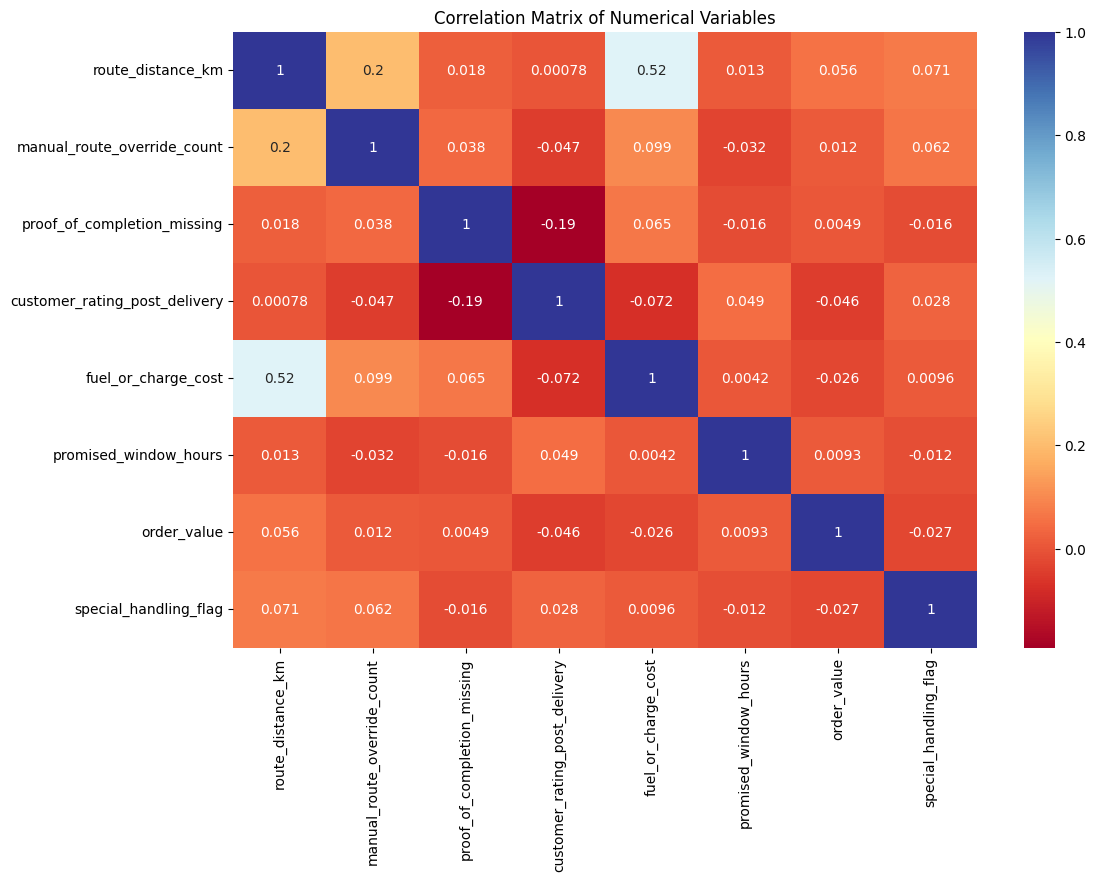

In [16]:
# Create a correlation matrix for numerical variables

correlation_matrix = numerical_columns.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="RdYlBu"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

**Interpretation**

The correlation matrix visualised relationships between numerical operational variables within the NorthStar dataset. Stronger positive or negative correlations suggest that certain operational factors influence one another. For example, delivery-related costs, route distances, delays, customer ratings, or operational efficiency indicators may show measurable relationships. Correlation analysis helps identify hidden operational patterns that may not be visible through isolated reporting systems.

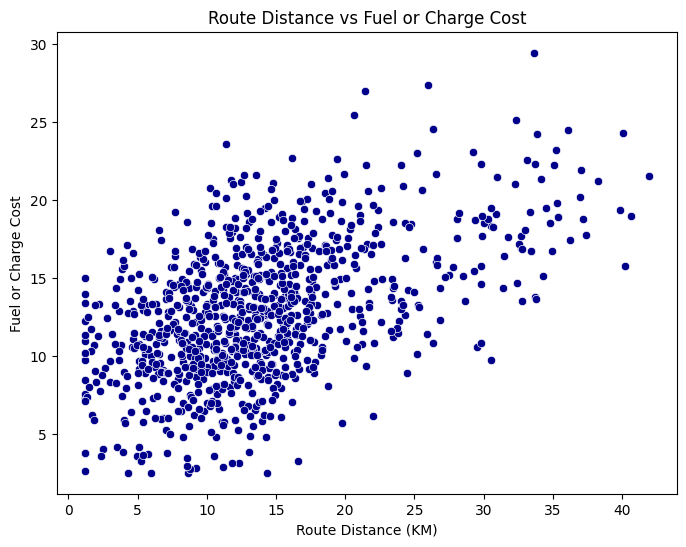

In [22]:
# Route distance vs cost
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="route_distance_km",
    y="fuel_or_charge_cost",
    data=combined_data,
    color="darkblue"
)

plt.title("Route Distance vs Fuel or Charge Cost")
plt.xlabel("Route Distance (KM)")
plt.ylabel("Fuel or Charge Cost")
plt.show()

**Interpretation**

The scatter plot compared route distance with fuel or charging cost across delivery operations. The visualisation suggests that longer delivery distances generally contribute to higher operational costs. However, some shorter routes also appear costly, indicating that factors such as delays, traffic conditions, failed deliveries, or operational inefficiencies may also influence delivery expenses.

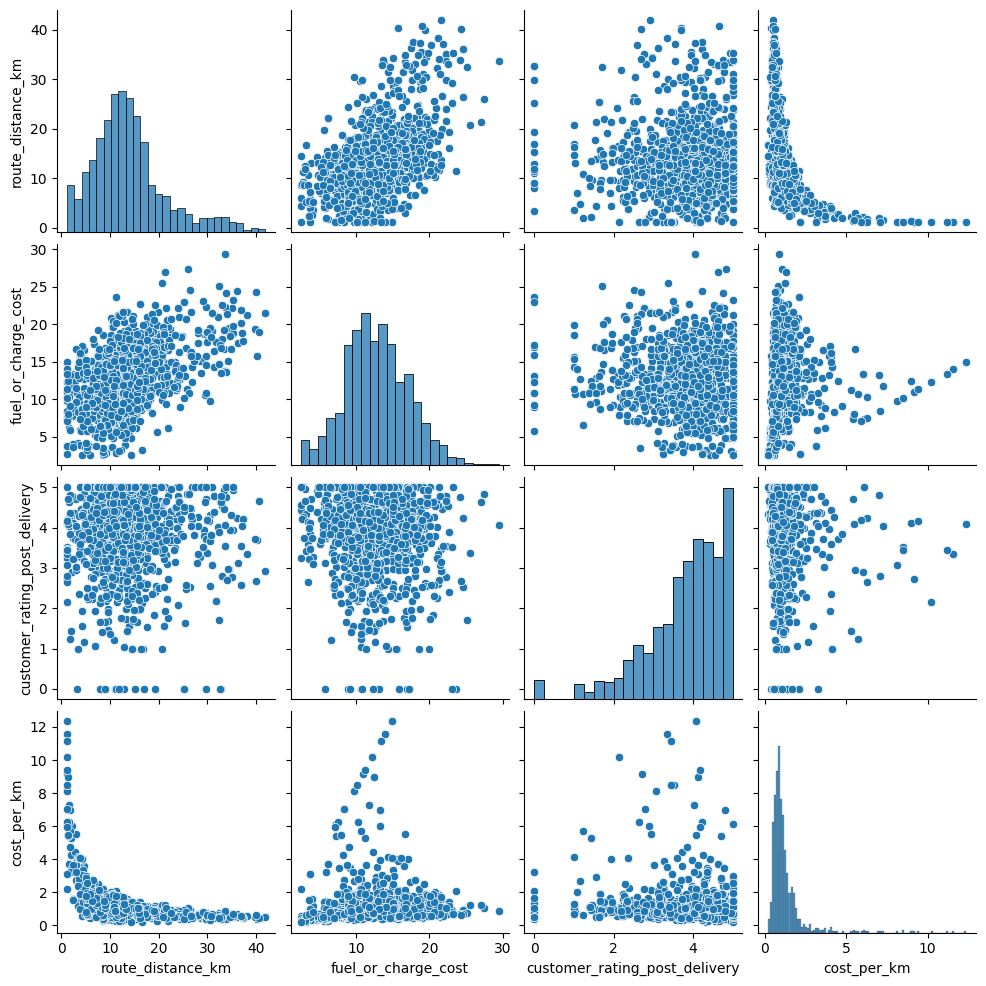

In [32]:
# Create a pair plot for important numerical variables

pairplot_data = combined_data[
    [
        "route_distance_km",
        "fuel_or_charge_cost",
        "customer_rating_post_delivery",
        "cost_per_km"
    ]
]

sns.pairplot(pairplot_data)

plt.show()

**Interpretation**

The pair plot visualised relationships between route distance, operational delivery cost, and customer ratings. The visualisation showed that higher delivery costs are often associated with longer delivery distances. Customer ratings also appeared to vary across operational conditions, suggesting that delivery performance may influence customer satisfaction. The pair plot provides a broader analytical view of how operational variables interact with one another.

In [25]:
# Analyse the frequency of complaint categories

complaint_counts = complaints[ "complaint_type"].value_counts()

print(complaint_counts)

complaint_type
Delay                101
MissedPickup          64
AppIssue              53
DriverBehaviour       51
SupportExperience     20
Billing               16
Damage                15
Name: count, dtype: int64


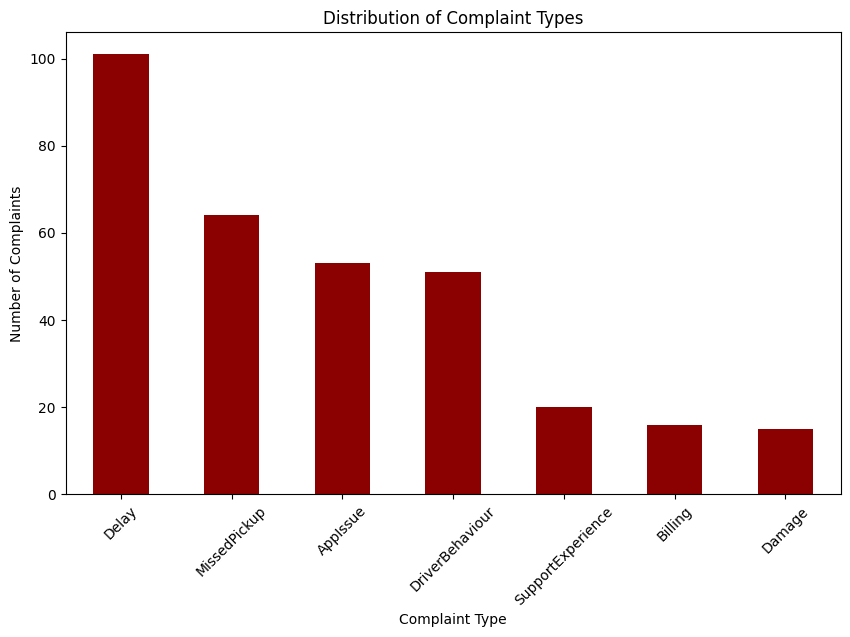

In [26]:
# Create a coloured bar chart showing complaint categories

plt.figure(figsize=(10,6))

complaint_counts.plot(
    kind="bar",
    color="darkred"
)

plt.title("Distribution of Complaint Types")

plt.xlabel("Complaint Type")

plt.ylabel("Number of Complaints")

plt.xticks(rotation=45)

plt.show()

**Interpretation**

The complaint analysis identified the most common customer complaint categories within NorthStar operations. High frequencies of complaints related to delays, missed pickups, app issues, or driver behaviour suggest recurring operational weaknesses within the service network. These findings support the case study concern that customer dissatisfaction is increasing due to operational inefficiencies and fragmented service management systems.

In [27]:
# Analyse average operational cost by hub

hub_analysis = combined_data.groupby(
    "hub_id"
)["fuel_or_charge_cost"].mean()

print(hub_analysis)

hub_id
H01    12.755809
H02    12.565000
H03    12.744202
H04    13.167008
H05    13.686000
H06    13.319231
H07    12.922087
H08    11.708203
Name: fuel_or_charge_cost, dtype: float64


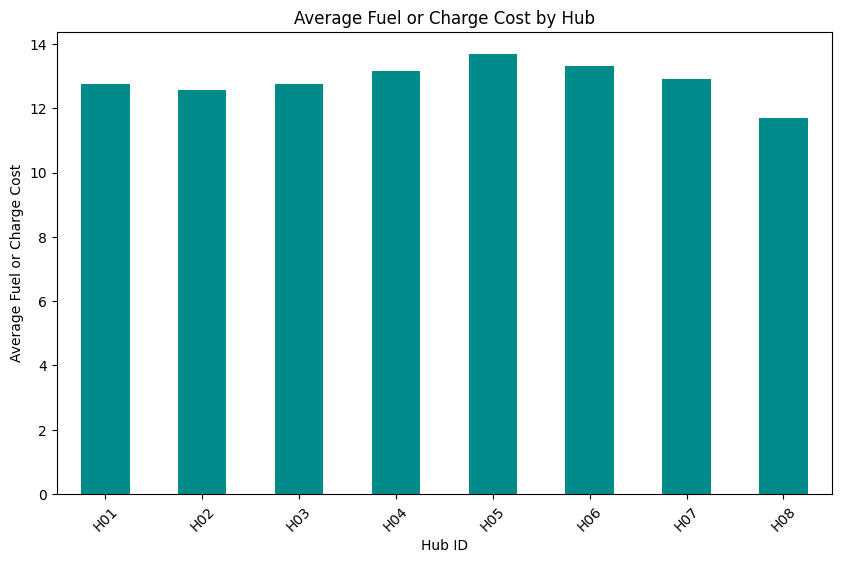

In [28]:
# Create a bar chart showing average operational cost by hub

plt.figure(figsize=(10,6))

hub_analysis.plot(
    kind="bar",
    color="darkcyan"
)

plt.title("Average Fuel or Charge Cost by Hub")

plt.xlabel("Hub ID")

plt.ylabel("Average Fuel or Charge Cost")

plt.xticks(rotation=45)

plt.show()

**Interpretation**

The hub performance analysis showed that operational costs vary across NorthStar hubs. Some hubs recorded higher average fuel or charging costs than others, suggesting uneven operational efficiency across the network. These differences may be caused by route allocation issues, traffic conditions, delivery delays, energy consumption, or operational planning inefficiencies.

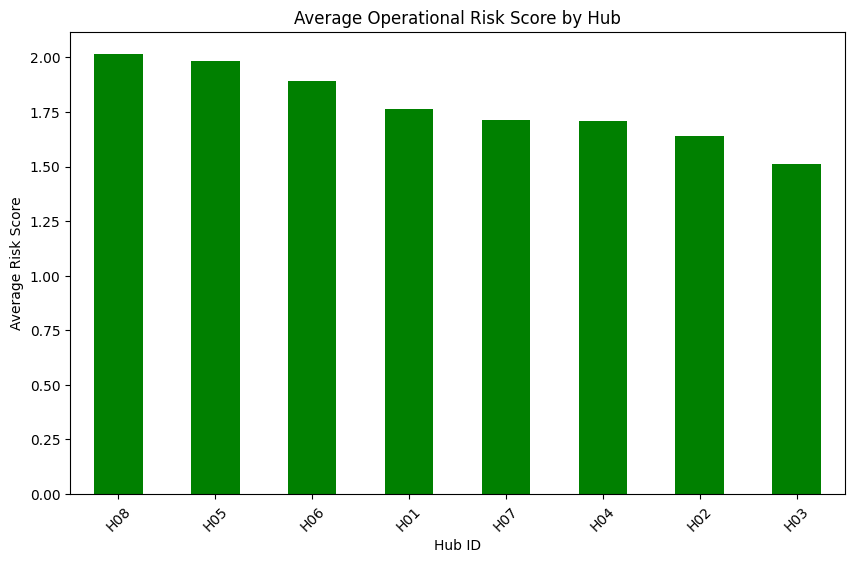

In [31]:
# Hub risk chart
plt.figure(figsize=(10, 6))

hub_risk_summary["average_risk_score"].plot(
    kind="bar",
    color="green"
)

plt.title("Average Operational Risk Score by Hub")
plt.xlabel("Hub ID")
plt.ylabel("Average Risk Score")
plt.xticks(rotation=45)
plt.show()

### **Interpretation**

The hub risk chart visualised the average operational risk score for each hub. This makes it easier to identify which hubs may require management attention. Hubs with higher risk scores may be experiencing repeated delivery failures, delays, manual route overrides, or lower customer ratings, suggesting possible weaknesses in route planning, staffing, or operational control.

## ***Key Findings And Analytical Summary***

The Python analytics investigation identified several important operational and analytical issues within NorthStar Urban Mobility and Logistics. The combined dataset analysis demonstrated that operational costs, delivery performance, customer satisfaction, and complaint patterns are closely connected across the organisation.

The statistical analysis showed considerable variation in delivery costs, suggesting that operational efficiency is inconsistent across routes and hubs. Correlation analysis further indicated that operational variables such as route distance, delivery cost, and customer ratings may influence one another, revealing hidden operational relationships within the network.

The complaint analysis identified recurring operational problems involving delays, missed pickups, app-related issues, and driver behaviour. These findings support the case study concern that customer dissatisfaction is increasing due to operational reliability problems and fragmented systems.

Hub-level analysis also demonstrated that certain hubs experience higher average operational costs, suggesting uneven service efficiency and possible route planning or resource allocation issues.

Overall, the Python analysis highlighted the importance of integrating operational, customer, and service datasets to uncover hidden inefficiencies and support better data-driven decision-making across NorthStar’s operations.